## **Prep** ##

In [1]:
library(sf)
library(dplyr)

Linking to GEOS 3.10.2, GDAL 3.4.1, PROJ 8.2.1; sf_use_s2() is TRUE


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




**Load Data Frames**

In [2]:
shape <- st_read("Combined_Parcels_2024.shp")
classifications <- read.csv("Parcel_Classifications_2023.csv")
ratio <- read.csv("Combined_Study_2023.csv")
ratio2 = read.csv("Combined_Study_2024.csv")
exc <- read.csv("Combined_Reconciliation_2023.csv")
exc2 <- read.csv("Combined_Reconciliation_2024.csv")
ctyb = st_read('Combined_County_Boundaries_2024.shp')

Reading layer `Combined_Parcels_2024' from data source 
  `/anvil/projects/x-cis220051/sps/tippecanoe-project/Combined_Parcels_2024.shp' 
  using driver `ESRI Shapefile'


Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
"GDAL Message 1: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection."
Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
"GDAL Message 1: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection."
Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
"GDAL Message 1: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection."
Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
"GDAL Message 1: organizePolygons() recei

Simple feature collection with 3521572 features and 10 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 403530.9 ymin: 4180997 xmax: 692092.3 ymax: 4625472
Projected CRS: NAD83 / UTM zone 16N
Reading layer `Combined_County_Boundaries_2024' from data source 
  `/anvil/projects/x-cis220051/sps/tippecanoe-project/Combined_County_Boundaries_2024.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 92 features and 12 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 403540.1 ymin: 4180914 xmax: 692185.5 ymax: 4625472
Projected CRS: NAD83 / UTM zone 16N


**Combine Data Frames**

In [3]:
shape = shape[!is.na(shape$PrprtyC),]
combinedclass <- inner_join(shape, classifications, by = c("PrclNmb" = "ParcelNumber"),relationship='many-to-many')
ratio = rbind(ratio,ratio2[ratio2$County == 'Whitley',])
combinedrat <- inner_join(combinedclass, ratio, by = c("PrclNmb" = "ParcelNumber"),relationship = "many-to-many")
exc = rbind(exc,exc2[exc2$County == 'Whitley',])
combinedexc = inner_join(combinedclass, exc, by = c("PrclNmb" = "ParcelNumber"),relationship = "many-to-many")

**Split Data Frames**

In [4]:
combinedexc = combinedexc[combinedexc$Explanation %in% c('AV DOES NOT REFLECT MARKET VALUE','MULTI PARCEL SALE','INVESTMENT/RENTAL','SOLD AS IS',
               'INSUFFICIENT TIME ON MARKET','VACANT LAND','APARTMENT','LEASE','BUILDING PERMIT',
               'NOT ENOUGH SALES FOR TRENDING'),]

In [5]:
combinedexc = combinedexc[,c(1:10,12:29)]
combinedrat = combinedrat[,c(1:10,12:29)]

In [6]:
combinedclass = rbind(combinedexc,combinedrat)

In [7]:
rural = combinedclass[combinedclass$ZipClassification == "Rural",]
urban = combinedclass[combinedclass$ZipClassification == "Urban",]

## **K Means** ##

### Rural Parcels

In [ ]:
## Create 7 clusters on the sold Rural Parcels using the KMeans clustering algorithm
library(ggplot2)
# Extract longitude and latitude coordinates to create the clusters
coords <- cbind(
  as.numeric(rural$Longitd),
  as.numeric(rural$Latitud)
)
coords <- na.omit(coords)
coords <- as.matrix(coords)
coords_df <- as.data.frame(coords)
names(coords_df) <- c("Long", "Lat")

set.seed(42)

num_clusters <- 7

## Create the clusters and assign each Rural Parcel to its respective cluster
kmeans_result <- kmeans(coords_df, centers = num_clusters)
coords_df$Cluster <- as.factor(kmeans_result$cluster)

points_sf <- st_as_sf(coords_df, coords = c("Long", "Lat"), crs = 4326)
rural$Cluster <- as.factor(kmeans_result$cluster)


   1    2    3    4    5    6    7 
3453 5123 5762 4576 3278 5424 6958 

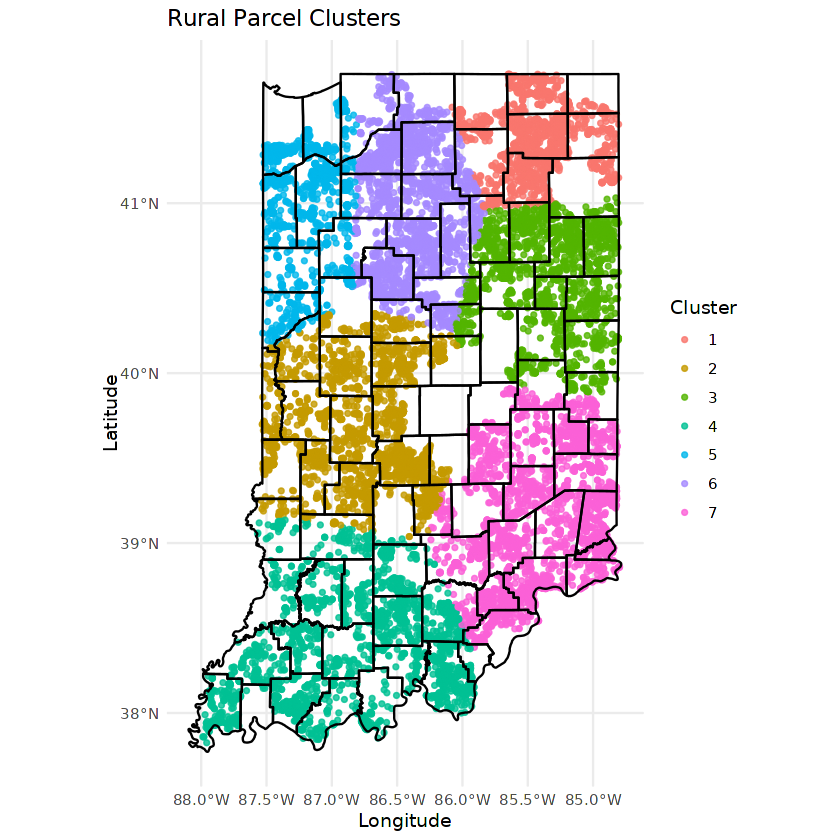

In [ ]:
## Map the Rural Parcel Clusters and show how many Parcels are in each Cluster
ggplot() +
  geom_sf(data = points_sf, aes(color = Cluster), alpha = 0.8, size = 1) +
 geom_sf(data = ctyb, 
          fill = NA, color = "black", size = 0.5,lwd=0.5) +
  theme_minimal() +
  labs(title = "Rural Parcel Clusters", x = "Longitude", y = "Latitude", color = "Cluster")

table(rural$Cluster)

In [ ]:
## Create a map for each cluster that highlights the chosen cluster in more detail
unique_clusters <- unique(points_sf$Cluster)

for (cluster in unique_clusters) {
  
  # Set transparency: 1 for primary cluster, 0.1 for others
  points_clustered <- points_sf %>%
    mutate(alpha = ifelse(Cluster == cluster, 1, 0.1),size = ifelse(Cluster == cluster, 0.7, 0.2))
  
  
  p = ggplot() +
    geom_sf(data = points_clustered, aes(geometry = geometry, color = Cluster, alpha = alpha,size=size)) +
    geom_sf(data = ctyb, fill = NA, color = "black", size = 0.5, lwd = 0.5) +
    guides(size = "none") +
    scale_alpha_identity() +
    theme_minimal() +
    labs(
      title = paste("Rural Parcel Clusters - Cluster", cluster),
      x = "Longitude", y = "Latitude",
      color = "Cluster"
    )
    ggsave(
    filename = paste0("cluster_pictures/cluster_",cluster, ".jpg"),
    plot = p,
    width = 8, height = 6,
    dpi = 300
  )
    
}

#### **Urban**


    8     9    10    11    12    13    14 
 8236 18765  5201 47512  5891  8582  7448 

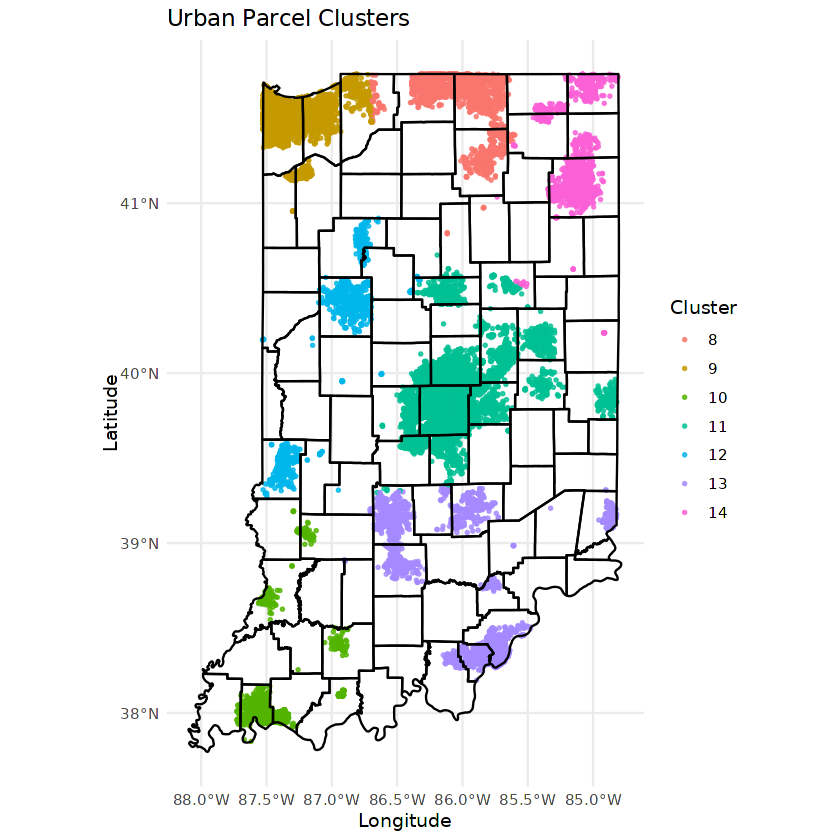

In [ ]:
## Create 7 clusters on the sold Urban Parcels using the KMeans clustering algorithm

coords <- cbind(
  as.numeric(urban$Longitd),
  as.numeric(urban$Latitud)
)
coords <- na.omit(coords)
coords <- as.matrix(coords)
coords_df <- as.data.frame(coords)
names(coords_df) <- c("Long", "Lat")

set.seed(42)

num_clusters <- 7

## Create the clusters and assign each Rural Parcel to its respective cluster
kmeans_result <- kmeans(coords_df, centers = num_clusters)
coords_df$Cluster <- as.factor(kmeans_result$cluster + 7)

points_sf <- st_as_sf(coords_df, coords = c("Long", "Lat"), crs = 4326)
urban$Cluster <- as.factor(kmeans_result$cluster + 7)

## Map the Urban Parcel Clusters and show how many Parcels are in each Cluster
ggplot() +
  geom_sf(data = points_sf, 
          aes(color = as.factor(Cluster)), 
          alpha = 0.8, size = 0.5) +
  geom_sf(data = ctyb, 
          fill = NA, color = "black", size = 0.5,lwd=0.5) +
  theme_minimal() +
  labs(title = "Urban Parcel Clusters", 
       x = "Longitude", y = "Latitude", color = "Cluster")

table(urban$Cluster)

In [ ]:
## Create a map for each cluster that highlights the chosen cluster in more detail

unique_clusters <- unique(points_sf$Cluster)

for (cluster in unique_clusters) {
  
  # Set transparency: 1 for primary cluster, 0.1 for others
  points_clustered <- points_sf %>%
    mutate(alpha = ifelse(Cluster == cluster, 1, 0.05),size = ifelse(Cluster == cluster, 3, 0.1))
  
  p = ggplot() +
    geom_sf(data = points_clustered, aes(geometry = geometry, color = Cluster, alpha = alpha,size=size)) +
    geom_sf(data = ctyb, fill = NA, color = "black", size = 0.5, lwd = 0.5) +
    guides(size = "none") +
    scale_alpha_identity() +
    theme_minimal() +
    labs(
      title = paste("Urban Parcel Clusters - Cluster", cluster),
      x = "Longitude", y = "Latitude",
      color = "Cluster"
    )
    ggsave(
    filename = paste0("cluster_pictures/cluster_",cluster, ".jpg"),
    plot = p,
    width = 8, height = 6,
    dpi = 300
  )
    
}

In [ ]:
## Combine Rural and Urban Parcels and clusters into one data frame to use for new ratio studies
final = rbind(rural,urban)
final = st_drop_geometry(final)
final = final[,c(1,11,12,13,14,15,16,17,18,29)]
colnames(final)[colnames(final) == 'PrclNmb'] = 'ParcelNumber'
colnames(final)[colnames(final) == 'Zip.y'] = 'Zip'
colnames(final)[colnames(final) == 'County.y'] = 'County'
colnames(final)[colnames(final) == 'Township.x'] = 'Township'
colnames(final)[colnames(final) == 'TaxDistrict.x'] = 'TaxDistrict'
head(final)

In [53]:
write.csv(final,'Parcel_Clusters_2023.csv')